# 03 — Modelos estadísticos

## Objetivo

Construir modelos estadísticos de referencia para estimar las principales
componentes del riesgo:

- frecuencia de siniestros;
- severidad;
- prima pura mediante frecuencia × severidad;
- costo agregado mediante un modelo directo.

Estos modelos funcionarán como *baseline* para comparar posteriormente métodos
de Machine Learning y Deep Learning.

La evaluación se realizará sobre una partición de prueba independiente y,
cuando sea posible, también contra las cantidades verdaderas generadas por el
DGP sintético.

Las variables *oracle* se utilizarán exclusivamente para evaluación y nunca
como predictores durante el entrenamiento.

### 1.1 Imports

In [3]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [5]:
from src.evaluation.metrics import (
    regression_metrics,
    poisson_metrics,
    relative_improvement
)

from src.evaluation.calibration import (
    calibration_by_quantile
)

from src.evaluation.diagnostics import (
    glm_dispersion
)
print(PROJECT_ROOT)
print(sys.path[:3])

c:\Users\derec\Desktop\Proyectos\Modelos_estadisticosvsMLvsDeep-Learning
['c:\\Users\\derec\\Desktop\\Proyectos\\Modelos_estadisticosvsMLvsDeep-Learning', 'c:\\Users\\derec\\anaconda3\\envs\\GLMvsML\\python311.zip', 'c:\\Users\\derec\\anaconda3\\envs\\GLMvsML\\DLLs']


In [31]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

SEED = 42

### 1.2 Carga de datos

In [32]:
DATA_PATH = Path("../data/raw/synthetic_insurance_portfolio.csv")

df = pd.read_csv(DATA_PATH)

print(f"Observaciones: {len(df):,}")
print(f"Variables: {df.shape[1]}")

Observaciones: 10,000
Variables: 15


In [33]:
# Etiquetas categóricas
df["zona_cat"] = df["zona"].map({
    1: "Muy bajo",
    2: "Bajo",
    3: "Medio",
    4: "Alto",
    5: "Muy alto"
})

df["cobertura_cat"] = df["cobertura"].map({
    0: "Limitada",
    1: "RC",
    2: "Amplia"
})

df["tipo_uso_cat"] = df["tipo_uso"].map({
    0: "Particular",
    1: "Transporte privado",
    2: "Carga comercial"
})

### 1.3 Definición de variables

In [34]:
# Variables independientes
FEATURES = [
    "edad",
    "zona",
    "anios_vehiculo",
    "cobertura",
    "historial_siniestros",
    "tipo_uso"
]

# Variables dependientes
TARGET_FREQUENCY = "numero_siniestros"
TARGET_SEVERITY = "severidad_promedio"
TARGET_COST = "costo_siniestros"

# Variables para validar resultados
ORACLE = [
    "lambda_real",
    "prob_siniestro_real",
    "severidad_esperada_real",
    "prima_pura_real"
]

# Validar que ninguna variable oracle puede entrar como predictor
assert not set(FEATURES) & set(ORACLE)

### 1.4 Train/Test split

In [35]:
train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.20,
    random_state=SEED
)

df_train = df.loc[train_idx].copy()
df_test = df.loc[test_idx].copy()

print(f"Train: {len(df_train):,}")
print(f"Test:  {len(df_test):,}")

Train: 8,000
Test:  2,000


In [36]:
# Resumen del split, verificar que las frecuencias sean comparables
split_summary = pd.DataFrame({
    "train": [
        df_train["numero_siniestros"].mean(),
        df_train["tuvo_siniestro"].mean(),
        df_train["costo_siniestros"].mean()
    ],
    "test": [
        df_test["numero_siniestros"].mean(),
        df_test["tuvo_siniestro"].mean(),
        df_test["costo_siniestros"].mean()
    ]
}, index=[
    "frecuencia_media",
    "proporcion_con_siniestro",
    "costo_medio"
])

split_summary

,train,test
frecuencia_media,0.154875,0.157500
proporcion_con_siniestro,0.141375,0.146000
costo_medio,1936.977709,2008.681614


In [37]:
split_df = pd.DataFrame({
    "policy_id": df["policy_id"],
    "split": np.where(
        df.index.isin(train_idx),
        "train",
        "test"
    )
})

split_df.head()

,policy_id,split
0,1,test
1,2,train
2,3,train
3,4,test
4,5,train


In [38]:
SPLIT_PATH = Path("../data/processed/train_test_split.csv")

SPLIT_PATH.parent.mkdir(
    parents=True,
    exist_ok=True
)

split_df.to_csv(
    SPLIT_PATH,
    index=False
)

## 2. Modelo GLM Poisson para frecuencia

La variable `numero_siniestros` representa un conteo no negativo. El análisis
exploratorio mostró además que su media y varianza marginales son similares,
por lo que un modelo Poisson constituye un punto de partida natural.

Se supone que:

$$
N_i \mid X_i \sim Poisson(\lambda_i)
$$

y se utiliza un enlace logarítmico:

$$
\log(\lambda_i)=X_i^\top\beta.
$$

De esta manera:

$$
E[N_i\mid X_i]
=
\lambda_i
=
\exp(X_i^\top\beta).
$$

La exponenciación de los coeficientes permite interpretar los parámetros como
efectos multiplicativos sobre la frecuencia esperada.

In [39]:
# Formula que indica la regresión lineal poisson
formula_poisson_1 = """
numero_siniestros ~
edad +
anios_vehiculo +
C(zona_cat) +
C(cobertura_cat) +
historial_siniestros +
C(tipo_uso_cat)
"""

In [40]:
# Ajuste del GLM Poisson
poisson_1 = smf.glm(
    formula=formula_poisson_1,
    data=df_train,
    family=sm.families.Poisson()
).fit()

print(poisson_1.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:      numero_siniestros   No. Observations:                 8000
Model:                            GLM   Df Residuals:                     7988
Model Family:                 Poisson   Df Model:                           11
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3471.6
Date:              lun., 21 sep. 2026   Deviance:                       4616.4
Time:                        21:51:54   Pearson chi2:                 7.86e+03
No. Iterations:                     6   Pseudo R-squ. (CS):            0.03822
Covariance Type:            nonrobust                                         
                                            coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

### 2.3 Coeficientes como efectos multiplicativos

Una de las grandes ventajas del GLM Poisson con enlace log es:

$$
\log(\lambda) = X\beta
$$

por lo que: 

$$
\lambda = e^{X\beta}
$$

Entonces:

$$
e^{\beta_j}
$$

puede interpretarse como un **factor multiplicativo sobre la frecuencia esperada**, manteniendo lo demás constante.

In [41]:
coef_table = pd.DataFrame({
    "coef": poisson_1.params,
    "exp_coef": np.exp(poisson_1.params),
    "p_value": poisson_1.pvalues
})

coef_table

,coef,exp_coef,p_value
Intercept,-1.743861,0.174844,2.569805e-30
C(zona_cat)[T.Bajo],-0.254291,0.775466,4.602263e-03
C(zona_cat)[T.Medio],-0.226725,0.797140,1.207079e-02
C(zona_cat)[T.Muy alto],0.225852,1.253390,5.072698e-03
C(zona_cat)[T.Muy bajo],-0.449840,0.637730,2.276374e-06
C(cobertura_cat)[T.Limitada],-0.217514,0.804516,2.287038e-03
C(cobertura_cat)[T.RC],-0.188364,0.828313,1.636456e-02
C(tipo_uso_cat)[T.Particular],-0.244790,0.782869,1.343451e-02
C(tipo_uso_cat)[T.Transporte privado],-0.179523,0.835669,7.194929e-02
edad,-0.003776,0.996231,2.991666e-02


De acuerdo al primer ajuste que se realizo, podemos explicar lo siguiente:

- historial_siniestros (Coef: 0.3481 | $p < 0.001$): Por cada siniestro adicional en el historial del cliente, la frecuencia esperada de siniestros aumenta aproximadamente un $41.6\%$ ($\exp(0.3481) - 1$), manteniendose constantes las demás variables.

- anios_vehiculo (Coef: 0.0160 | $p = 0.001$): A mayor antigüedad del vehículo, mayor siniestralidad. Por cada año extra de antigüedad del auto, la frecuencia esperada aumenta un $1.6\%$ ($\exp(0.0160) - 1$).

- edad (Coef: -0.0038 | $p = 0.030$): Bajo la especificación lineal actual, el modelo estima una reducción promedio de aproximadamente $0.38\%$ ($\exp(-0.0038) - 1$) por año. Sin embargo, el EDA sugirió una relación no lineal, por lo que este coeficiente podría estar resumiendo inadecuadamente el efecto real de la edad.

 - zona_cat (Zona de riesgo): La categoría de referencia es "Alto". 
    - Muy alto: Presenta un aumento significativo del riesgo ($+25.3\%$) respecto a la zona de referencia.
    - Muy bajo, Bajo y Medio: Tienen un riesgo significativamente menor (por ejemplo, estar en una zona Muy bajo reduce el riesgo un $36.2\%$ respecto a la zona base).

- cobertura_cat (Tipo de cobertura): Manteniendo constantes las demás variables, las pólizas Limitadas presentan una frecuencia esperada aproximadamente 19.5% inferior a las de cobertura Amplia, mientras que RC presenta una frecuencia aproximadamente 17.2% inferior.

- tipo_uso_cat (Uso del vehículo)La categoría de referencia es "carga comercial".
   - El uso Particular reduce el riesgo un $21.7\%$ ($p = 0.013$).
   - El uso Transporte privado no alcanza significancia estadística del $5\%$ ($p = 0.072$), por lo que no hay suficiente evidencia para rechazar: $H_0: \beta_{\text{Transporte privado}}=0$

#### 2.3.1 Análisis de sobredispersión y Pseudo $R^2$

La dispersión de Pearson de de 0.984, aproximadamente 1 y menor que uno, eso no da una pista de que hay equidispersión, por lo que un modelo Poisson es una gran opción.

Respecto a la pseudo $R^2$ es de 0.038, pero esto tiene sentido ya que, la frecuencia media es de apenas 0.155, hay mucha variabilidad individual dificil de predecir.

Ejemplo:

Dos asegurados con exactamente el mismo $X$ pueden tener:

$$
N_1=0, N_2=1
$$

simplemente por azar.

In [42]:
pearson_dispersion = (
    poisson_1.pearson_chi2 /
    poisson_1.df_resid
)

print(f"Dispersión Pearson φ: {pearson_dispersion:.4f}")
print(f"Pseudo R^2: {0.03822}")

Dispersión Pearson φ: 0.9841
Pseudo R^2: 0.03822


### 2.4 Mejora del modelo: efecto no lineal de edad

En el Análisis explotatorio observamos que:

$$
\text{Frecuencia}\uparrow \text{hasta edades intermedia y después, Frecuencia}\downarrow
$$

Pero el modelo actual impone una recta:

$$
\log(\lambda) = \beta_0 + B_1edad + ...
$$

Pero el comportamiento de edad es similar a una parabola, por lo que haremos:

$$
\text{edad}^2.
$$

Pero primero vamos a restarle media de la edad del portafolio, para evitar problemas de multicolinealidad.


#### Demostración de restar media a una variable evita tener multicolinealidad

Sea $Z = X - \mu_X$, de modo que por construcción $E[Z] = 0$.
Queremos calcular la covarianza entre la variable centrada $Z$ y su cuadrado $Z^2$:

$$\text{Cov}(Z, Z^2) = E[(Z - E[Z])(Z^2 - E[Z^2])]$$

Como $E[Z] = 0$, esto se simplifica a:

$$\text{Cov}(Z, Z^2) = E[Z \cdot (Z^2 - E[Z^2])]$$

$$\text{Cov}(Z, Z^2) = E[Z^3] - E[Z] \cdot E[Z^2]$$

Como $E[Z] = 0$:
$$\text{Cov}(Z, Z^2) = E[Z^3]$$

$E[Z^3]$ es el tercer momento central (relacionado con el sesgo o skewness). Si la distribución de edad es simétrica alrededor de su media, $E[Z^3] = 0$.

Por lo tanto, $\text{Cov}(Z, Z^2) = 0$, haciendo que la correlación sea exactamente 0.

In [ ]:
edad_media_train = df_train["edad"].mean()

df_train["edad_c"] = (
    df_train["edad"] - edad_media_train
)

df_test["edad_c"] = (
    df_test["edad"] - edad_media_train
)

df_train["edad_c2"] = df_train["edad_c"] ** 2
df_test["edad_c2"] = df_test["edad_c"] ** 2

In [44]:
formula_poisson_2 = """
numero_siniestros ~
edad_c +
edad_c2 +
anios_vehiculo +
C(zona_cat) +
C(cobertura_cat) +
historial_siniestros +
C(tipo_uso_cat)
"""

In [45]:
poisson_2 = smf.glm(
    formula=formula_poisson_2,
    data=df_train,
    family=sm.families.Poisson()
).fit()

print(poisson_2.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:      numero_siniestros   No. Observations:                 8000
Model:                            GLM   Df Residuals:                     7987
Model Family:                 Poisson   Df Model:                           12
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3463.3
Date:              lun., 21 sep. 2026   Deviance:                       4599.8
Time:                        21:52:07   Pearson chi2:                 7.83e+03
No. Iterations:                     6   Pseudo R-squ. (CS):            0.04022
Covariance Type:            nonrobust                                         
                                            coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

In [46]:
comparison_poisson = pd.DataFrame({
    "Modelo": [
        "Poisson lineal",
        "Poisson + edad²"
    ],
    "LogLik": [
        poisson_1.llf,
        poisson_2.llf
    ],
    "AIC": [
        poisson_1.aic,
        poisson_2.aic
    ],
    "Deviance": [
        poisson_1.deviance,
        poisson_2.deviance
    ],
    "Pearson dispersion": [
        poisson_1.pearson_chi2 / poisson_1.df_resid,
        poisson_2.pearson_chi2 / poisson_2.df_resid
    ]
})

comparison_poisson

,Modelo,LogLik,AIC,Deviance,Pearson dispersion
0,Poisson lineal,-3471.603440,6967.206881,4616.444300,0.984119
1,Poisson + edad²,-3463.288926,6952.577851,4599.815271,0.980739


### Efecto no lineal de la edad

El modelo que incorpora un término cuadrático para la edad presenta una mejora
respecto a la especificación exclusivamente lineal.

El coeficiente asociado con `edad_c2` es negativo y estadísticamente
significativo, lo que indica una relación cóncava entre edad y frecuencia
esperada. La frecuencia aumenta hasta alcanzar un máximo alrededor de las
edades intermedias y posteriormente disminuye.

Este comportamiento es consistente con el patrón identificado previamente
durante el análisis exploratorio.

Además, la inclusión del término cuadrático mejora el log-likelihood y reduce
la devianza y el AIC, mientras que los coeficientes asociados con las demás
variables permanecen prácticamente estables.

Por esta razón, la especificación cuadrática de edad se conservará en el modelo
Poisson de referencia.

In [ ]:

y_train_freq = df_train["numero_siniestros"]
y_test_freq = df_test["numero_siniestros"]

pred_train_freq = poisson_2.predict(df_train)
pred_test_freq = poisson_2.predict(df_test)

In [48]:
frequency_calibration = pd.DataFrame({
    "Muestra": ["Train", "Test"],
    "Frecuencia observada": [
        y_train_freq.mean(),
        y_test_freq.mean()
    ],
    "Frecuencia predicha": [
        pred_train_freq.mean(),
        pred_test_freq.mean()
    ]
})

frequency_calibration

,Muestra,Frecuencia observada,Frecuencia predicha
0,Train,0.154875,0.154875
1,Test,0.157500,0.153042


En la muestra de entrenamiento, la frecuencia media observada y la frecuencia
media estimada son prácticamente idénticas. Esta coincidencia se deriva en gran
medida de las propiedades del ajuste del GLM Poisson con intercepto y no implica
que el modelo pueda predecir exactamente los siniestros individuales.

En la muestra de prueba, la frecuencia observada es 0.1575 siniestros por
póliza, mientras que el modelo estima aproximadamente 0.1530. La diferencia es
pequeña, lo que indica una buena calibración agregada fuera de muestra.

Sin embargo, la comparación de medias únicamente evalúa la calibración global.
Para determinar si el modelo discrimina correctamente entre pólizas de
diferente nivel de riesgo es necesario estudiar la calibración a lo largo de
la distribución de las predicciones y utilizar métricas específicas para datos
de conteo.

### 2.5 Evaluación out-of-sample del modelo Poisson

In [51]:
def frequency_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred))
    }

In [52]:
baseline_pred = np.full(
    len(df_test),
    y_train_freq.mean()
)

baseline_metrics = frequency_metrics(
    y_test_freq,
    baseline_pred
)

poisson_metrics = frequency_metrics(
    y_test_freq,
    pred_test_freq
)

pd.DataFrame(
    [baseline_metrics, poisson_metrics],
    index=["Baseline media", "GLM Poisson"]
)

,MAE,RMSE
Baseline media,0.267152,0.397115
GLM Poisson,0.255862,0.390971


### 2.6 Poisson Deviance


In [53]:
from sklearn.metrics import mean_poisson_deviance

In [54]:
poisson_deviance_model = mean_poisson_deviance(
    y_test_freq,
    pred_test_freq
)

poisson_deviance_baseline = mean_poisson_deviance(
    y_test_freq,
    baseline_pred
)

print(
    f"Poisson Deviance - Baseline: "
    f"{poisson_deviance_baseline:.4f}"
)

print(
    f"Poisson Deviance - GLM: "
    f"{poisson_deviance_model:.4f}"
)

Poisson Deviance - Baseline: 0.6152
Poisson Deviance - GLM: 0.5872


In [55]:
deviance_reduction = (
    1
    - poisson_deviance_model
    / poisson_deviance_baseline
)

print(
    f"Reducción relativa de deviance: "
    f"{deviance_reduction:.2%}"
)

Reducción relativa de deviance: 4.56%


### 2.7 Gráfico de calibración

In [56]:
calibration_df = pd.DataFrame({
    "observado": y_test_freq.values,
    "predicho": np.asarray(pred_test_freq)
})

calibration_df["decil_riesgo"] = pd.qcut(
    calibration_df["predicho"],
    q=10,
    duplicates="drop"
)

calibration_by_decile = (
    calibration_df
    .groupby("decil_riesgo", observed=True)
    .agg(
        frecuencia_observada=("observado", "mean"),
        frecuencia_predicha=("predicho", "mean"),
        polizas=("observado", "size")
    )
    .reset_index()
)

calibration_by_decile

,decil_riesgo,frecuencia_observada,frecuencia_predicha,polizas
0,"(0.0393, 0.0793]",0.085,0.068226,200
1,"(0.0793, 0.0924]",0.105,0.085795,200
2,"(0.0924, 0.104]",0.115,0.098234,200
3,"(0.104, 0.116]",0.085,0.109273,200
4,"(0.116, 0.13]",0.130,0.122221,200
5,"(0.13, 0.146]",0.135,0.137198,200
6,"(0.146, 0.168]",0.185,0.156438,200
7,"(0.168, 0.195]",0.180,0.180767,200
8,"(0.195, 0.255]",0.235,0.219961,200
9,"(0.255, 0.821]",0.320,0.352311,200


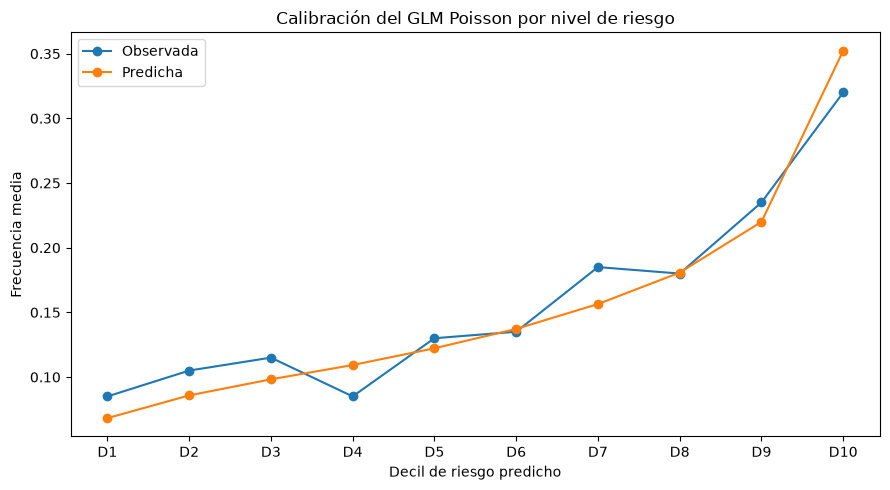

In [57]:
x = np.arange(len(calibration_by_decile))

plt.figure(figsize=(9, 5))

plt.plot(
    x,
    calibration_by_decile["frecuencia_observada"],
    marker="o",
    label="Observada"
)

plt.plot(
    x,
    calibration_by_decile["frecuencia_predicha"],
    marker="o",
    label="Predicha"
)

plt.xticks(
    x,
    [f"D{i}" for i in range(1, len(x) + 1)]
)

plt.xlabel("Decil de riesgo predicho")
plt.ylabel("Frecuencia media")
plt.title("Calibración del GLM Poisson por nivel de riesgo")
plt.legend()

plt.tight_layout()
plt.show()

### Evaluación out-of-sample

El GLM Poisson presenta una mejora respecto al modelo baseline que asigna la
misma frecuencia esperada a todas las pólizas.

El MAE disminuye de aproximadamente 0.267 a 0.256 y el RMSE de 0.397 a 0.391.
La mejora es moderada, lo que refleja la dificultad de predecir realizaciones
individuales de una variable de conteo con una fuerte componente aleatoria.

La Poisson deviance disminuye de 0.6152 a 0.5872, equivalente a una reducción
relativa aproximada de 4.56% frente al baseline. Esto indica que las
características incluidas en el modelo permiten explicar una parte de la
heterogeneidad observada en la frecuencia.

El análisis por deciles muestra además una capacidad razonable para discriminar
entre pólizas de diferente nivel de riesgo. La frecuencia estimada aumenta
progresivamente desde aproximadamente 0.068 en el primer decil hasta 0.352 en
el décimo. La frecuencia observada presenta un patrón general similar, aunque
con fluctuaciones atribuibles a la variabilidad muestral.

En términos generales, el modelo presenta una calibración adecuada, aunque se
observan pequeñas diferencias en algunos segmentos, particularmente en los
extremos de la distribución de riesgo.

Estos resultados sugieren que el GLM Poisson constituye un baseline estadístico
competitivo y correctamente calibrado para la posterior comparación con
modelos de Machine Learning y Deep Learning.

### 2.8 Evaluación contra la frecuencia verdadera (*oracle*)

A diferencia de la evaluación tradicional contra el número de siniestros
observado, en este experimento sintético conocemos la frecuencia verdadera
generada para cada póliza, `lambda_real`.

Esto permite comparar directamente:

$$
\hat{\lambda}_i
$$

con:

$$
\lambda_i^{real}.
$$

En la muestra de prueba, el modelo obtiene:

- MAE *oracle*: 0.0136
- RMSE *oracle*: 0.0179
- Correlación entre frecuencia real y estimada: 0.9814

Estos resultados indican que el GLM Poisson recupera con bastante precisión la
estructura de riesgo utilizada para generar los datos.

El gráfico de frecuencia real contra frecuencia estimada muestra que la mayor
parte de las observaciones se concentra cerca de la línea de predicción
perfecta. Las desviaciones son mayores en algunos niveles de riesgo elevados,
donde también existe una menor cantidad de observaciones.

La diferencia entre los errores obtenidos contra `numero_siniestros` y contra
`lambda_real` es importante. El conteo observado contiene variabilidad aleatoria
propia del proceso Poisson:

$$
N_i \mid X_i \sim Poisson(\lambda_i),
$$

por lo que incluso un modelo que estimara correctamente $(\lambda_i)$ no podría
predecir exactamente la realización individual $(N_i)$.

Por esta razón, el error frente a `lambda_real` permite evaluar de manera más
directa la capacidad del modelo para recuperar la verdadera función de riesgo,
separando el error de modelado de la variabilidad aleatoria inherente al
fenómeno.

In [58]:
lambda_true_test = df_test["lambda_real"]

oracle_mae = mean_absolute_error(
    lambda_true_test,
    pred_test_freq
)

oracle_rmse = np.sqrt(
    mean_squared_error(
        lambda_true_test,
        pred_test_freq
    )
)

print(f"Oracle MAE:  {oracle_mae:.6f}")
print(f"Oracle RMSE: {oracle_rmse:.6f}")

Oracle MAE:  0.013578
Oracle RMSE: 0.017865


In [59]:
oracle_corr = np.corrcoef(
    lambda_true_test,
    pred_test_freq
)[0, 1]

print(
    f"Correlación con lambda real: "
    f"{oracle_corr:.4f}"
)

Correlación con lambda real: 0.9814


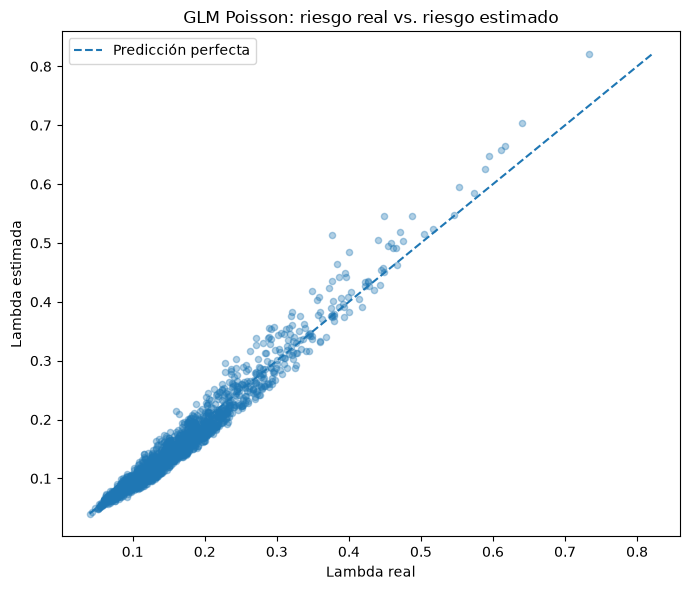

El ajuste es bastante bueno: la mayoría de los puntos están muy cerca de la diagonal. 
Hay algo más de desviación para riesgos altos, donde además tenemos menos observaciones, 
pero el GLM está recuperando muy bien la estructura generadora


In [61]:
plt.figure(figsize=(7, 6))

plt.scatter(
    lambda_true_test,
    pred_test_freq,
    alpha=0.35,
    s=20
)

min_val = min(
    lambda_true_test.min(),
    pred_test_freq.min()
)

max_val = max(
    lambda_true_test.max(),
    pred_test_freq.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    label="Predicción perfecta"
)

plt.xlabel("Lambda real")
plt.ylabel("Lambda estimada")
plt.title("GLM Poisson: riesgo real vs. riesgo estimado")
plt.legend()

plt.tight_layout()
plt.show()
print("El ajuste es bastante bueno: la mayoría de los puntos están muy cerca de la diagonal. \n" \
"Hay algo más de desviación para riesgos altos, donde además tenemos menos observaciones, \n" \
"pero el GLM está recuperando muy bien la estructura generadora")

### Consideración metodológica

La evaluación contra `lambda_real` únicamente es posible porque el conjunto de
datos fue generado de manera sintética y el proceso generador es conocido.

En un problema real, la frecuencia esperada individual:

$$
\lambda_i = E[N_i \mid X_i]
$$

es una cantidad latente que no puede observarse directamente. Para cada póliza
solo se dispone del número de siniestros efectivamente ocurrido durante el
período analizado.

Por este motivo, en aplicaciones reales la calidad del modelo debe evaluarse
de manera indirecta mediante métricas out-of-sample, devianza, calibración y
comparaciones entre siniestros observados y esperados en grupos suficientemente
grandes de pólizas.

La disponibilidad de una variable *oracle* constituye una de las principales
ventajas del diseño sintético de este proyecto, ya que permitirá comparar de
forma controlada qué tan bien los modelos estadísticos, de Machine Learning y
de Deep Learning recuperan la verdadera estructura subyacente del riesgo.

### Conclusión del modelo de frecuencia

El GLM Poisson presenta un desempeño satisfactorio como modelo estadístico de
referencia.

La incorporación de un término cuadrático para la edad mejora la especificación
del modelo y permite representar la relación no lineal detectada durante el
análisis exploratorio. Los demás coeficientes son estables y presentan efectos
consistentes con los patrones observados previamente.

Los diagnósticos de dispersión no muestran evidencia relevante de
sobredispersión residual, mientras que la evaluación out-of-sample indica una
mejora moderada frente a un modelo baseline y una calibración razonable a lo
largo de los distintos niveles de riesgo.

Finalmente, la evaluación contra la frecuencia verdadera muestra que el modelo
recupera con elevada precisión la función generadora del riesgo, con una
correlación de aproximadamente 0.98 entre la frecuencia real y la estimada.

Por estas razones, este GLM Poisson se conservará como el baseline estadístico
de frecuencia para la posterior comparación con modelos de Machine Learning y
Deep Learning.